TensorFlow Version : 2.20.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Dataset Loaded Successfully

Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images  : (10000, 28, 28)
Testing Labels  : (10000,)


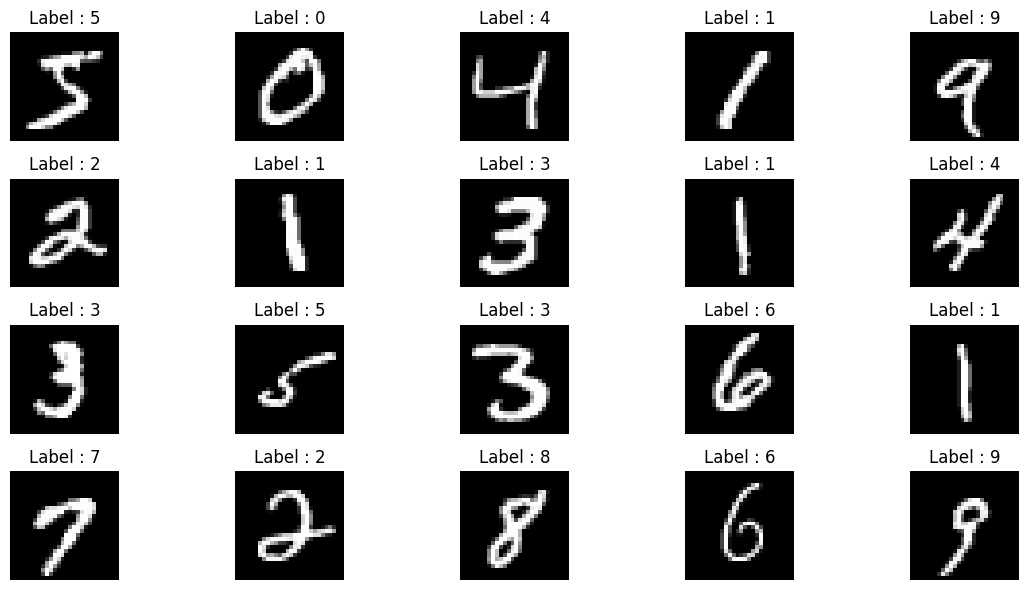


Data Preprocessing Completed Successfully!

New Shape of Training Images : (60000, 28, 28, 1)
New Shape of Testing Images  : (10000, 28, 28, 1)

ImageDataGenerator Ready!


In [1]:
# ============================================================
# HANDWRITTEN DIGIT RECOGNIZER USING CNN
# Internship Project - Codec Technologies
# Author: Your Name
# ============================================================

# -----------------------------
# Import Required Libraries
# -----------------------------

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("="*60)
print("TensorFlow Version :", tf.__version__)
print("="*60)

# -----------------------------
# Load Dataset
# -----------------------------

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("\nDataset Loaded Successfully\n")

print("Training Images :", x_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images  :", x_test.shape)
print("Testing Labels  :", y_test.shape)

# -----------------------------
# Display Sample Images
# -----------------------------

plt.figure(figsize=(12,6))

for i in range(20):
    plt.subplot(4,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label : {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# -----------------------------
# Data Preprocessing
# -----------------------------

# Normalize images

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape for CNN

x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

# Convert labels to One-Hot Encoding

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print("\nData Preprocessing Completed Successfully!\n")

print("New Shape of Training Images :", x_train.shape)
print("New Shape of Testing Images  :", x_test.shape)

# -----------------------------
# Data Augmentation
# -----------------------------

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.10,
    width_shift_range=0.10,
    height_shift_range=0.10
)

datagen.fit(x_train)

print("\nImageDataGenerator Ready!")

In [2]:
# ============================================================
# BUILDING THE CNN MODEL
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Create the CNN model
model = Sequential([

    # First Convolution Block
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    # Second Convolution Block
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    # Third Convolution Block
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.30),

    # Fully Connected Layers
    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.40),

    Dense(128, activation='relu'),
    Dropout(0.30),

    Dense(10, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 5, 5, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 5, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,258 (1.16 MB)

 Trainable params: 304,810 (1.16 MB)

 Non-trainable params: 448 (1.75 KB)

In [3]:
# ============================================================
# TRAIN THE MODEL
# ============================================================

# Stop training if validation accuracy doesn't improve
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Save the best model automatically
checkpoint = ModelCheckpoint(
    "digit_recognizer.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

print("="*60)
print("Training Started...")
print("="*60)

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    validation_data=(x_test, y_test),
    epochs=20,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("\nTraining Completed Successfully!")

Training Started...
Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.6599 - loss: 1.0382
Epoch 1: val_accuracy improved from None to 0.98130, saving model to digit_recognizer.keras

Epoch 1: finished saving model to digit_recognizer.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 261s 273ms/step - accuracy: 0.8350 - loss: 0.5138 - val_accuracy: 0.9813 - val_loss: 0.0606
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.9562 - loss: 0.1493
Epoch 2: val_accuracy improved from 0.98130 to 0.98990, saving model to digit_recognizer.keras

Epoch 2: finished saving model to digit_recognizer.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 255s 271ms/step - accuracy: 0.9603 - loss: 0.1376 - val_accuracy: 0.9899 - val_loss: 0.0316
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.9696 - loss: 0.1110
Epoch 3: val_accuracy improved from 0.98990 to 0.99290, saving model to digit_recognizer.keras

Epoch 3: finished saving model to digit_recognizer.keras
938/938 ━━━━━━━━━━

Test Accuracy : 99.29%
Test Loss     : 0.0252


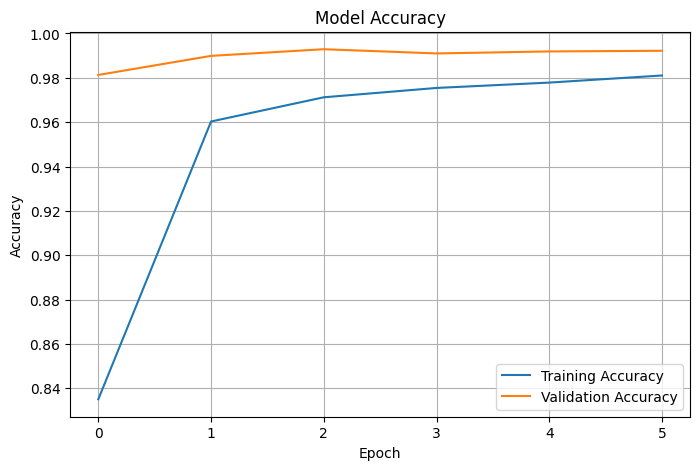

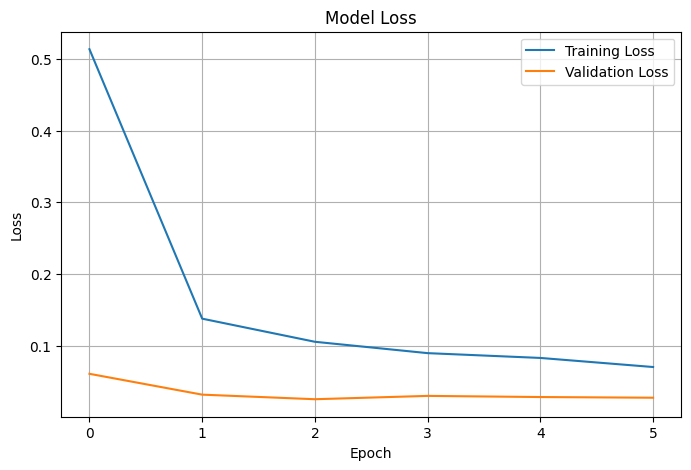

In [4]:
# ============================================================
# EVALUATE THE MODEL
# ============================================================

import matplotlib.pyplot as plt

# Evaluate on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print("="*60)
print(f"Test Accuracy : {test_accuracy*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")
print("="*60)

# ============================================================
# PLOT TRAINING ACCURACY
# ============================================================

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# PLOT TRAINING LOSS
# ============================================================

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step


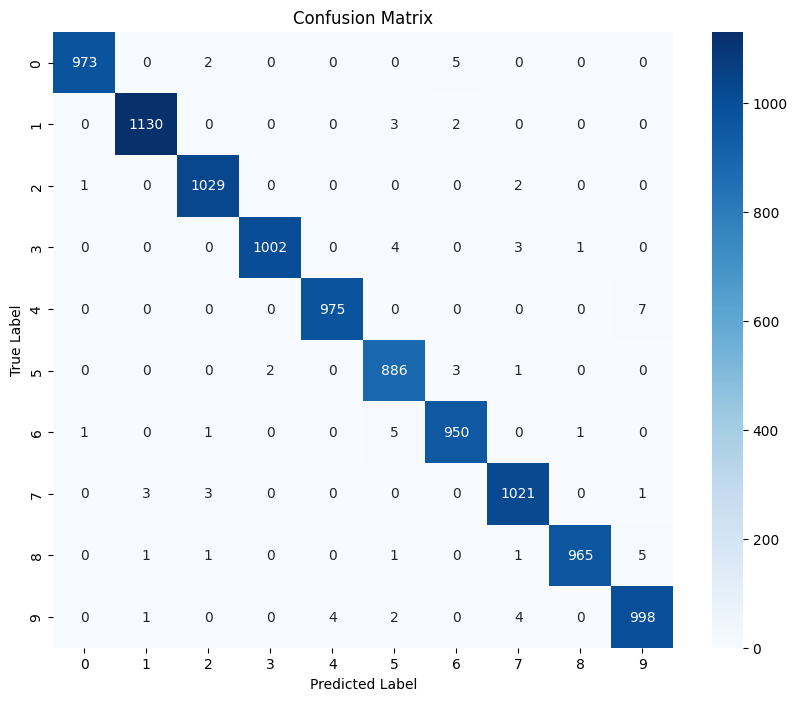


Classification Report

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       980
           1       1.00      1.00      1.00      1135
           2       0.99      1.00      1.00      1032
           3       1.00      0.99      1.00      1010
           4       1.00      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [5]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Predict on test data
predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(10,8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("\nClassification Report\n")

print(classification_report(true_labels, predicted_labels))

In [6]:
# ============================================
# Upload an Image
# ============================================

from google.colab import files

uploaded = files.upload()

Saving download (3).jpg to download (3).jpg


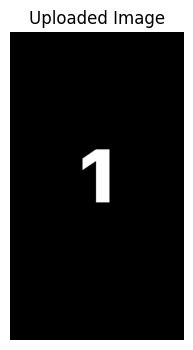

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted Digit : 1
Confidence      : 88.90%


In [7]:
# ============================================
# Predict Uploaded Image
# ============================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

filename = list(uploaded.keys())[0]

img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(4,4))
plt.imshow(img, cmap="gray")
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

# Invert image if background is white
if np.mean(img) > 127:
    img = 255 - img

img = cv2.resize(img, (28,28))

img = img.astype("float32") / 255.0

img = img.reshape(1,28,28,1)

prediction = model.predict(img)

digit = np.argmax(prediction)

confidence = np.max(prediction) * 100

print("="*50)
print(f"Predicted Digit : {digit}")
print(f"Confidence      : {confidence:.2f}%")
print("="*50)

In [8]:
from google.colab import files

files.download("digit_recognizer.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>